In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
torch.__version__

'2.10.0+cpu'

In [ ]:
#use the linear regression formula to make a stright line with known **parameters Y = mx+b
weight = 0.7
bias = 0.3

#create
start = 0
end = 1
step = 0.02

X = torch.arange(start, end , step).unsqueeze(dim=1)
y = weight * X + bias

In [ ]:
X[:10] , y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

In [ ]:
#create a train test split
train_split = int(0.8 * len(X))

#splittting the data
X_train, y_train = X[:train_split] , y[:train_split]
X_test , y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [ ]:
from numpy import size
#creating the visualization

def plot_function(train_data=X_train,
                  train_labels=y_train,
                  test_data = X_test,
                  test_labels=y_test,
                  Predictions=None):
  """
  creatingg the Matplot lib function
  """
  plt.figure(figsize=(10,7))
  #plotting for the training data
  plt.scatter(train_data,train_labels, c='b',s=4, label='Training Data')

  #plotting for the test data

  plt.scatter(test_data, test_labels, c='g',s=4, label='Test Data')
  #plotting for the predictions
  if Predictions is not None:
    plt.scatter(test_data, Predictions, c='r', s=4, label='Predictions')

  plt.legend(prop={"size":14})

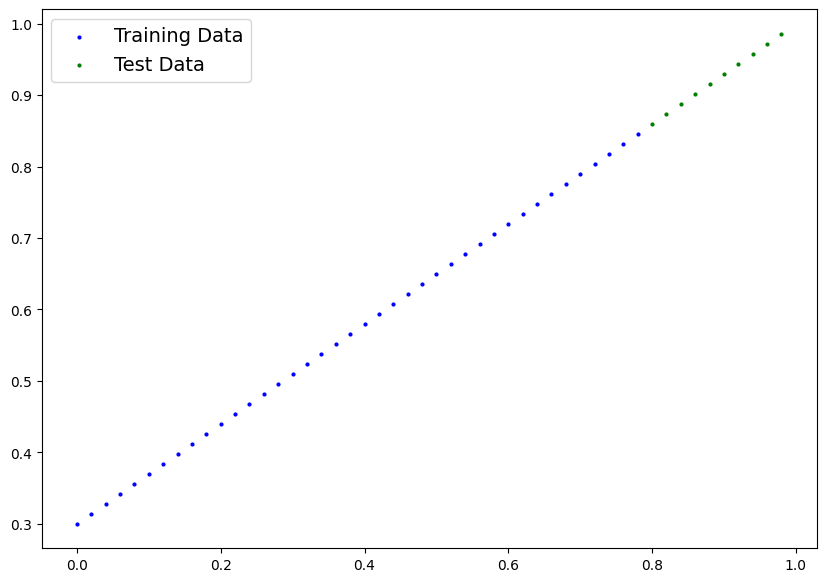

In [ ]:
plot_function()

Building the model In pytorch

In [ ]:
class LinearRegresisonScratch(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(1,requires_grad=True, dtype=torch.float32))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))

    #forward method to define the computation in the model

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias  #<-- this is the linera eq formula

 ### **Checking the model Content**

 using the `.parameters()`

In [ ]:
#creating the manual seed
torch.manual_seed(42)

#create the instance of the model
model_0 = LinearRegresisonScratch()

#checking the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
#list named parameetrs
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

 ### Making oprediction using `torch.inference_mode()`
 * what `inference_mode()` is doing it turn off the gradient tracking `require_grads=False`

 To check our model's predictive power , let's see how it will perform on the `y_test` based on `x_test`


In [ ]:
y_pred = model_0(X_test)
y_pred #<-- here we have the grad function on

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [ ]:
#make prediction with the Model
with torch.inference_mode(): #<-- what inference does here it turn off the gradient tracking
  y_pred = model_0(X_test)

y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

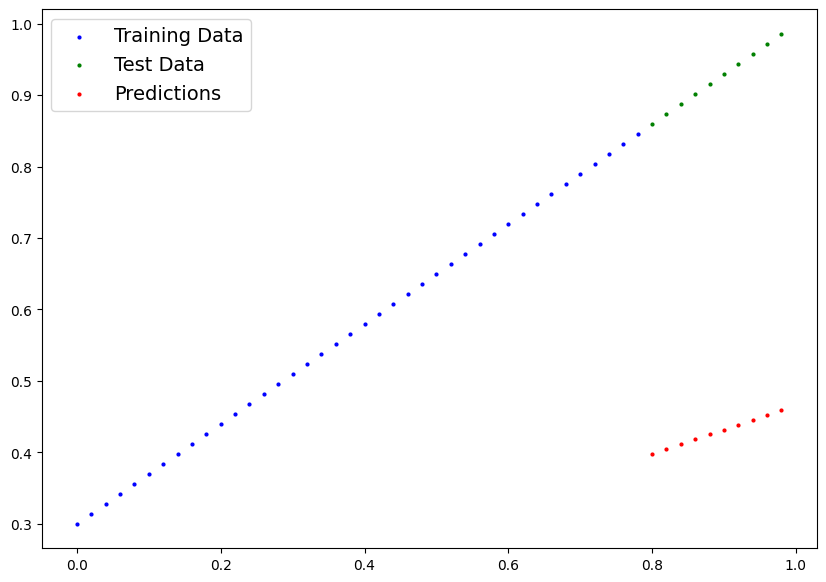

In [ ]:
plot_function(Predictions=y_pred)

# **Train Model**
 * one way to measure how por the model predictions is using the `loss Function`.

 * `Loss functions` also be called the `Cost Functions` or **Critrion** in different areas.

### **Things we need o train**
 * **Loss Function** : afunction to measure how wrong the model predictions are
 * **optimizer** : Takes into acocunt the model loss function and adjust the parameters (Weights and bias) to imrove the Loss function

 And specifically for pytorch we need ⁉
 * training loop
 * testing loop


In [ ]:
#setup a loss function
loss_fn = nn.L1Loss() #<-- mean abolute Error nn.L1Loss

#optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)

###Building a training loop

  0 . **Loop through data**

    1 . Forward pass (Forward propagation)

    2 . Calculate loss

    3 . optimize Zero Grad

    4 . Loss Backward (Backward Propagation)
    
    5 . Optimizer Step (Gradient Descent)

In [ ]:
#building a training Loop
epochs = 150
epoch_count = []
loss_values = []
test_loss_values = []
for epoch in range(epochs):
  model_0.train() #it puts the model into the learning mode

  #setting the Forward pass
  y_pred = model_0(X_train) #<-- this is the forward pass

  #calculating the loss
  loss = loss_fn(y_pred , y_train) #input first and target next

  #opyimizer Zero grad
  optimizer.zero_grad()

  #backprop
  loss.backward()

  #optimizer SGD
  optimizer.step()

  ###testing the model
  model_0.eval() #turn off the settings that are not needed for the evaliation
  with torch.inference_mode():# turn off the gradients tracking and other things not needed for evaluation
    test_pred = model_0(X_test)
    #calculate the loss for the Xtest
    test_loss = loss_fn(test_pred, X_test)


    # printing out what is happeing here

  if epoch % 10 ==0:
    # appending the empty lists
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

    # printing the values
    print(f"epoch:{epoch} | Test:{loss.item():.4f} | Test Loss: {test_loss.item():.4f} ")

epoch:0 | Test:0.3129 | Test Loss: 0.4481 
epoch:10 | Test:0.1977 | Test Loss: 0.3134 
epoch:20 | Test:0.0891 | Test Loss: 0.1843 
epoch:30 | Test:0.0531 | Test Loss: 0.1116 
epoch:40 | Test:0.0454 | Test Loss: 0.0806 
epoch:50 | Test:0.0417 | Test Loss: 0.0662 
epoch:60 | Test:0.0382 | Test Loss: 0.0559 
epoch:70 | Test:0.0348 | Test Loss: 0.0476 
epoch:80 | Test:0.0313 | Test Loss: 0.0396 
epoch:90 | Test:0.0279 | Test Loss: 0.0333 
epoch:100 | Test:0.0245 | Test Loss: 0.0275 
epoch:110 | Test:0.0210 | Test Loss: 0.0230 
epoch:120 | Test:0.0176 | Test Loss: 0.0200 
epoch:130 | Test:0.0142 | Test Loss: 0.0184 
epoch:140 | Test:0.0107 | Test Loss: 0.0187 


In [ ]:
loss_diff = abs(loss.item() - test_loss.item())
print(f"Difference: {loss_diff:.6f}")

Difference: 0.012937


In [ ]:
import numpy as np
train_loss_values = torch.tensor(loss_values).detach().numpy() # Here we are converting the torch tensor value to the Numpy as matplot lob work with the numpy
#.Detach() is used to detach the Gradients tracking which help the ocnversion to Numpy()

/tmp/ipykernel_25154/2156309133.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_loss_values = torch.tensor(loss_values).detach().numpy() # Here we are converting the torch tensor value to the Numpy as matplot lob work with the numpy


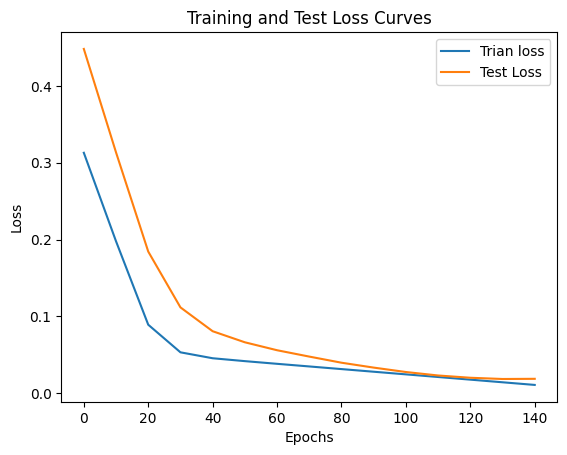

In [ ]:
#plotting the loss curve
plt.plot(epoch_count, train_loss_values, label='Trian loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.title('Training and Test Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6638])), ('bias', tensor([0.3153]))])

In [ ]:
weight , bias

(0.7, 0.3)

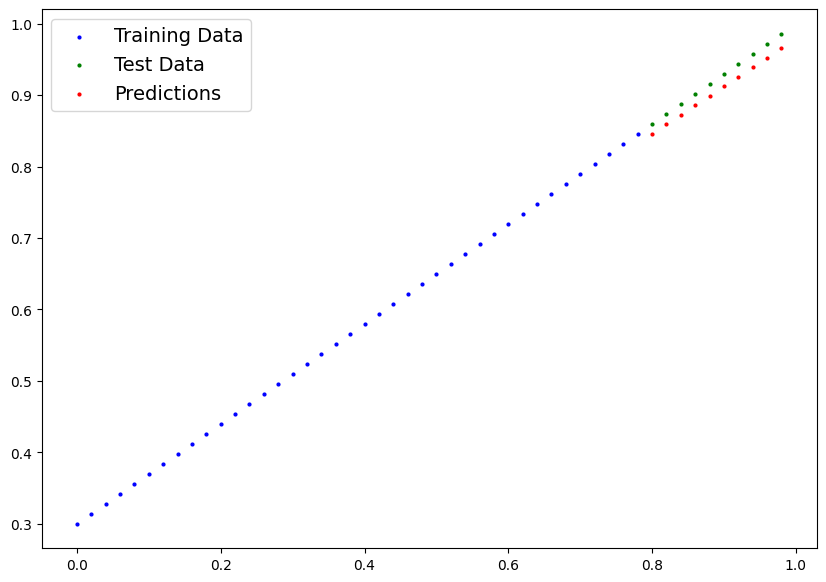

In [ ]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)

plot_function(Predictions=y_pred_new)

# Saving and Loading the pytorch model

`torch.save()`~ allow to save the PyTorch Object in python pickle format

`torch.load()`~ allow you to load the PyTroch object

`torch.nn.module.load_state_dict()`~ this allows to load a model saved state dictionary

In [ ]:
#saving the Model State Dict (Recomended)
from pathlib import Path
MAKE_PATH = Path('Models')
MAKE_PATH.mkdir(parents=True, exist_ok=True)

#2. Creating Model save Path
MODEL_NAME = 'model_pytorch_workflow_01.pth'

MODEL_SAVE_PATH = MAKE_PATH / MODEL_NAME
#3. Saving the model
print(f"Saving the model to :{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f = MODEL_SAVE_PATH)
print(f"Model Saved succeffully --> {MODEL_SAVE_PATH}")

Saving the model to :Models/model_pytorch_workflow_01.pth
Model Saved succeffully --> Models/model_pytorch_workflow_01.pth


In [ ]:
#1. Loading the model back
loaded_model = LinearRegresisonScratch()
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
print(f"Model Loaded Successfully")

Model Loaded Successfully
